# Linear Probing — MEB cardiaque

Évalue la séparabilité linéaire de chaque couche interne de TextureSAM
sur les patches annotés MEB via une régression logistique 5-fold stratifiée par image.

In [5]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import pickle
import h5py
import numpy as np
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report
from scipy.stats import mode
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

ROOT     = Path('..').resolve()
DB_PATH  = ROOT / 'data' / 'feature_database' / 'database_meb.h5'
CFG_PATH = ROOT / 'PatchTagger_Output' / 'config' / 'config.json'
OUT_DIR  = ROOT / 'outputs' / 'linear_probing_meb'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED    = 42
N_FOLDS = 5
MIN_N   = 30
C_REG   = 1.0

# Catégories exclues : ambiguës ou non texturales
CATS_EXCLUDE = {
    2,   # Plutôt homogène
    8,   # Sableux
    10,  # Bactéries
    11,  # (portion de) Cellule
    12,  # Calcification
    13,  # Nd
}

with open(CFG_PATH) as f:
    cfg = json.load(f)
CATEGORIES = {int(k): v['name'] for k, v in cfg['available_categories'].items()}

with h5py.File(DB_PATH, 'r') as h5:
    IMAGE_NAMES  = h5['metadata/image_names'][:]
    CATEGORY_IDS = h5['metadata/category_ids'][:]

CATS_VALID = sorted([
    int(c) for c in np.unique(CATEGORY_IDS)
    if (CATEGORY_IDS == c).sum() >= MIN_N
    and int(c) not in CATS_EXCLUDE
])
print(f'Catégories retenues ({len(CATS_VALID)}) :')
for c in CATS_VALID:
    print(f'  {c:2d}  {CATEGORIES[c]:<30}  N={(CATEGORY_IDS == c).sum()}')

_lp_mask_valid = np.isin(CATEGORY_IDS, CATS_VALID)
_lp_y_valid    = CATEGORY_IDS[_lp_mask_valid]
_lp_imgs_valid = IMAGE_NAMES[_lp_mask_valid]

# K-Fold stratifié sur les IMAGES (catégorie dominante par image)
_lp_images_uniq = np.unique(IMAGE_NAMES)
_lp_cat_dom = np.array([
    int(mode(CATEGORY_IDS[IMAGE_NAMES == img]).mode)
    for img in _lp_images_uniq
])

_lp_skf   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
_lp_FOLDS = list(_lp_skf.split(_lp_images_uniq, _lp_cat_dom))

print('\nVérification des folds :')
for _lp_fi, (_, _lp_test_idx) in enumerate(_lp_FOLDS):
    _lp_test_imgs = _lp_images_uniq[_lp_test_idx]
    _lp_mask_t    = np.isin(_lp_imgs_valid, _lp_test_imgs)
    _lp_cats_t    = set(np.unique(_lp_y_valid[_lp_mask_t]))
    _lp_missing   = set(CATS_VALID) - _lp_cats_t
    _lp_status    = '✅' if not _lp_missing else f'⚠️  manque {_lp_missing}'
    print(f'  Fold {_lp_fi+1} : {_lp_mask_t.sum():4d} patches test  {_lp_status}')

KEYS_ORDER = [
    'block_0',
    'block_1',  'block_2',
    'block_3',  'block_4',  'block_5',  'block_6',  'block_7',
    'block_8',  'block_9',  'block_10', 'block_11', 'block_12', 'block_13',
    'block_14', 'block_15',
    'stage_1_fpn', 'stage_2_fpn', 'stage_3_fpn', 'stage_4_fpn',
]

_lp_STAGE_ZONES = [
    ('Stage 1', [0],              '#DBEAFE', '#1D4ED8'),
    ('Stage 2', [1, 2],           '#D1FAE5', '#065F46'),
    ('Stage 3', list(range(3,14)),'#FEF3C7', '#92400E'),
    ('Stage 4', [14, 15],         '#FEE2E2', '#991B1B'),
    ('FPN',     [16,17,18,19],    '#EDE9FE', '#5B21B6'),
]

print(f'\nDB     : {DB_PATH}')
print(f'Output : {OUT_DIR}')

Catégories retenues (7) :
   1  Totalement homogène             N=41
   3  Faisceaux                       N=68
   4  Filaments                       N=49
   5  Stratifié rectiligne            N=64
   6  Stratifié sinueux               N=129
   7  Granuleux                       N=409
   9  Trou                            N=56

Vérification des folds :
  Fold 1 :  108 patches test  ✅
  Fold 2 :  135 patches test  ✅
  Fold 3 :  185 patches test  ✅
  Fold 4 :  187 patches test  ✅
  Fold 5 :  201 patches test  ⚠️  manque {1}

DB     : /home/aidouni/meb_texture_seg/data/feature_database/database_meb.h5
Output : /home/aidouni/meb_texture_seg/outputs/linear_probing_meb


/home/aidouni/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


## Cell 1 — Linear Probing par block

In [6]:
from sklearn.decomposition import PCA

_lp_results = {}
_lp_var_exp  = {}   # variance expliquée PCA par key (moyenne sur les folds)

PCA_DIM = 50

with h5py.File(DB_PATH, 'r') as h5:
    for _lp_key in tqdm(KEYS_ORDER, desc='Linear Probing'):

        _lp_X_all        = h5['features'][_lp_key][:][_lp_mask_valid]
        _lp_fold_accs    = []
        _lp_fold_per_cat = {c: [] for c in CATS_VALID}
        _lp_fold_var_exp = []

        for _lp_tr_idx, _lp_te_idx in _lp_FOLDS:
            _lp_train_imgs = _lp_images_uniq[_lp_tr_idx]
            _lp_test_imgs  = _lp_images_uniq[_lp_te_idx]

            _lp_m_train = np.isin(_lp_imgs_valid, _lp_train_imgs)
            _lp_m_test  = np.isin(_lp_imgs_valid, _lp_test_imgs)

            _lp_X_train = _lp_X_all[_lp_m_train]
            _lp_y_train = _lp_y_valid[_lp_m_train]
            _lp_X_test  = _lp_X_all[_lp_m_test]
            _lp_y_test  = _lp_y_valid[_lp_m_test]

            # ── PCA fit sur train uniquement ──────────────────────────────────
            _lp_n_comp   = min(PCA_DIM, _lp_X_train.shape[1])
            _lp_pca      = PCA(n_components=_lp_n_comp, random_state=SEED)
            _lp_X_tr_pca = _lp_pca.fit_transform(_lp_X_train)
            _lp_X_te_pca = _lp_pca.transform(_lp_X_test)
            _lp_fold_var_exp.append(_lp_pca.explained_variance_ratio_.sum())

            # ── StandardScaler sur les composantes PCA ────────────────────────
            _lp_scaler = StandardScaler()
            _lp_X_tr_n = _lp_scaler.fit_transform(_lp_X_tr_pca)
            _lp_X_te_n = _lp_scaler.transform(_lp_X_te_pca)

            _lp_clf = LogisticRegression(
                class_weight='balanced', max_iter=1000,
                C=C_REG, random_state=SEED, solver='lbfgs',
            )
            _lp_clf.fit(_lp_X_tr_n, _lp_y_train)
            _lp_y_pred = _lp_clf.predict(_lp_X_te_n)

            _lp_fold_accs.append(balanced_accuracy_score(_lp_y_test, _lp_y_pred))

            _lp_labels_fold = sorted(np.unique(_lp_y_test).tolist())
            _lp_report = classification_report(
                _lp_y_test, _lp_y_pred,
                labels=_lp_labels_fold, output_dict=True, zero_division=0,
            )
            for _lp_cat in CATS_VALID:
                _lp_r = _lp_report.get(str(_lp_cat), {}).get('recall', 0.0)
                _lp_fold_per_cat[_lp_cat].append(_lp_r)

        _lp_results[_lp_key] = {
            'acc_mean'   : float(np.mean(_lp_fold_accs)),
            'acc_std'    : float(np.std(_lp_fold_accs)),
            'folds'      : _lp_fold_accs,
            'acc_per_cat': {c: float(np.mean(_lp_fold_per_cat[c]))
                            for c in CATS_VALID},
        }
        _lp_var_exp[_lp_key] = float(np.mean(_lp_fold_var_exp))

        print(f'{_lp_key:15s} : '
              f'{_lp_results[_lp_key]["acc_mean"]*100:5.1f}% '
              f'± {_lp_results[_lp_key]["acc_std"]*100:4.1f}%  '
              f'[PCA {_lp_var_exp[_lp_key]*100:.1f}%]')

_lp_pkl = OUT_DIR / 'lp_results.pkl'
with open(_lp_pkl, 'wb') as _lp_f:
    pickle.dump({'results': _lp_results, 'var_exp': _lp_var_exp,
                 'cats_valid': CATS_VALID, 'keys_order': KEYS_ORDER,
                 'pca_dim': PCA_DIM}, _lp_f)
print(f'\n→ Résultats sauvegardés : {_lp_pkl}')

Linear Probing:   0%|          | 0/20 [00:00<?, ?it/s]

block_0         :  97.7% ±  3.4%  [PCA 100.0%]
block_1         :  92.6% ±  5.1%  [PCA 99.7%]
block_2         :  93.6% ±  4.6%  [PCA 99.5%]
block_3         :  94.7% ±  4.8%  [PCA 99.7%]
block_4         :  93.3% ±  5.2%  [PCA 98.6%]
block_5         :  91.9% ±  5.1%  [PCA 98.1%]
block_6         :  91.6% ±  6.1%  [PCA 97.5%]


/home/aidouni/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


block_7         :  89.1% ±  3.5%  [PCA 95.1%]
block_8         :  86.3% ±  5.9%  [PCA 94.4%]
block_9         :  87.0% ±  4.5%  [PCA 93.6%]


/home/aidouni/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


...

/home/aidouni/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


block_14        :  46.6% ± 11.9%  [PCA 92.1%]


/home/aidouni/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


block_15        :  44.4% ±  6.8%  [PCA 93.0%]
stage_1_fpn     :  97.1% ±  3.1%  [PCA 100.0%]
stage_2_fpn     :  94.2% ±  5.7%  [PCA 99.8%]
stage_3_fpn     :  66.7% ±  5.0%  [PCA 97.1%]
stage_4_fpn     :  43.6% ±  4.8%  [PCA 97.8%]

→ Résultats sauvegardés : /home/aidouni/meb_texture_seg/outputs/linear_probing_meb/lp_results.pkl


/home/aidouni/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## Cell 2 — Tableau console

In [7]:
_lp_baseline = 100.0 / len(CATS_VALID)
print(f'Baseline aléatoire = 1/{len(CATS_VALID)} = {_lp_baseline:.1f}%')
print(f'PCA : {PCA_DIM}d  (variance expliquée = moyenne sur les 5 folds)\n')

print(f'{"Block":<15} │ {"Acc macro":>12} │ {"Var. PCA":>8} │ '
      f'{"Meilleure cat":<28} │ {"Pire cat"}')
print('─' * 100)

for _lp_key in KEYS_ORDER:
    _lp_r      = _lp_results[_lp_key]
    _lp_acc    = _lp_r['acc_mean'] * 100
    _lp_std    = _lp_r['acc_std']  * 100
    _lp_vexp   = _lp_var_exp[_lp_key] * 100
    _lp_per_c  = _lp_r['acc_per_cat']
    _lp_best_c = max(_lp_per_c, key=_lp_per_c.get)
    _lp_wrst_c = min(_lp_per_c, key=_lp_per_c.get)
    print(
        f'{_lp_key:<15} │ {_lp_acc:>7.1f}% ±{_lp_std:4.1f} │ {_lp_vexp:>7.1f}% │ '
        f'{CATEGORIES[_lp_best_c]:<22} {_lp_per_c[_lp_best_c]*100:5.1f}%  │ '
        f'{CATEGORIES[_lp_wrst_c]:<22} {_lp_per_c[_lp_wrst_c]*100:5.1f}%'
    )

_lp_best_key = max(_lp_results, key=lambda k: _lp_results[k]['acc_mean'])
print(f'\nMeilleur block : {_lp_best_key} '
      f'→ {_lp_results[_lp_best_key]["acc_mean"]*100:.1f}% '
      f'± {_lp_results[_lp_best_key]["acc_std"]*100:.1f}%')
print(f'Amélioration vs baseline : '
      f'+{_lp_results[_lp_best_key]["acc_mean"]*100 - _lp_baseline:.1f}%')

Baseline aléatoire = 1/7 = 14.3%
PCA : 50d  (variance expliquée = moyenne sur les 5 folds)

Block           │    Acc macro │ Var. PCA │ Meilleure cat                │ Pire cat
────────────────────────────────────────────────────────────────────────────────────────────────────
block_0         │    97.7% ± 3.4 │   100.0% │ Stratifié rectiligne   100.0%  │ Totalement homogène     80.0%
block_1         │    92.6% ± 5.1 │    99.7% │ Stratifié rectiligne   100.0%  │ Faisceaux               58.9%
block_2         │    93.6% ± 4.6 │    99.5% │ Stratifié rectiligne   100.0%  │ Faisceaux               63.0%
block_3         │    94.7% ± 4.8 │    99.7% │ Stratifié rectiligne   100.0%  │ Faisceaux               71.9%
block_4         │    93.3% ± 5.2 │    98.6% │ Stratifié rectiligne   100.0%  │ Faisceaux               61.1%
block_5         │    91.9% ± 5.1 │    98.1% │ Stratifié rectiligne   100.0%  │ Faisceaux               57.4%
block_6         │    91.6% ± 6.1 │    97.5% │ Granuleux              

## Cell 3 — Figure courbe évolutive + heatmap

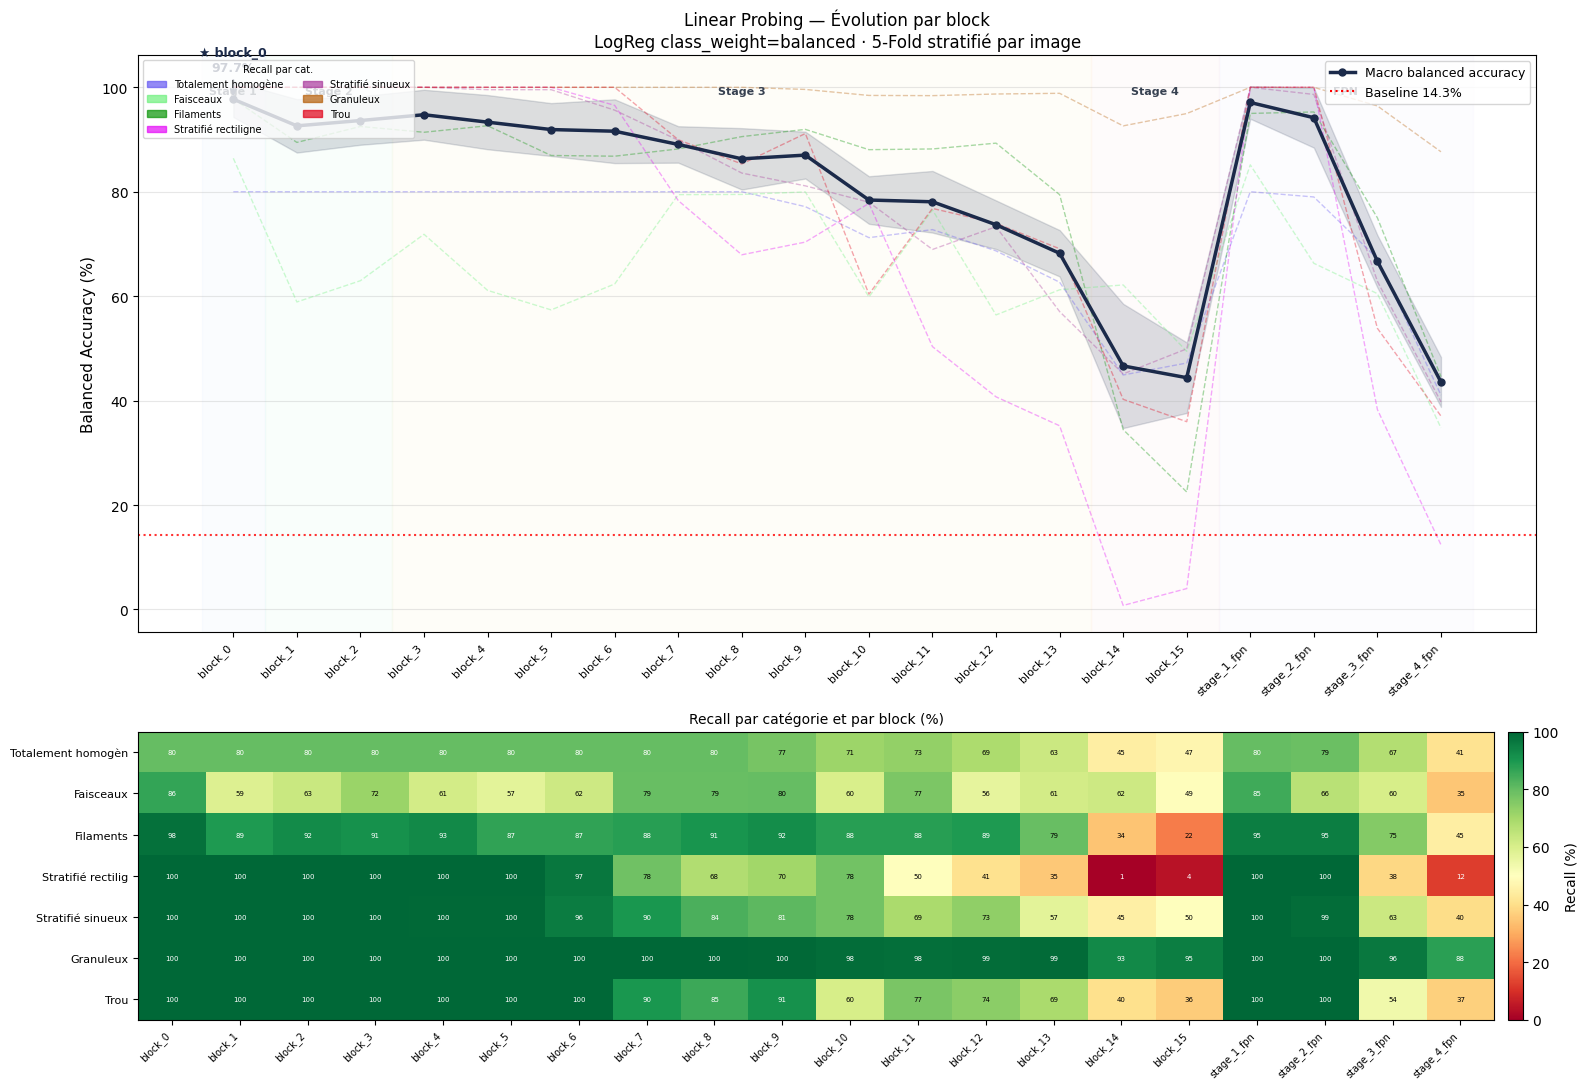

→ Figure sauvegardée : /home/aidouni/meb_texture_seg/outputs/linear_probing_meb/linear_probing_evolution.png


In [8]:
_lp_fig, (_lp_ax1, _lp_ax2) = plt.subplots(
    2, 1, figsize=(16, 11),
    gridspec_kw={'height_ratios': [2, 1]},
)

_lp_x       = np.arange(len(KEYS_ORDER))
_lp_y_macro = [_lp_results[k]['acc_mean'] * 100 for k in KEYS_ORDER]
_lp_y_std   = [_lp_results[k]['acc_std']  * 100 for k in KEYS_ORDER]
_lp_y_max   = max(_lp_y_macro)

# ── Subplot 1 — Courbe globale ────────────────────────────────────────────────
for _lp_label, _lp_idx, _lp_col, _ in _lp_STAGE_ZONES:
    _lp_ax1.axvspan(min(_lp_idx) - 0.5, max(_lp_idx) + 0.5,
                    alpha=0.12, color=_lp_col)
    _lp_ax1.text(
        (min(_lp_idx) + max(_lp_idx)) / 2, _lp_y_max * 1.01,
        _lp_label, ha='center', fontsize=8, color='#374151', fontweight='bold',
    )

# Courbes par catégorie (fines, transparentes)
_lp_cat_handles = []
for _lp_cat in CATS_VALID:
    _lp_y_cat = [_lp_results[k]['acc_per_cat'][_lp_cat] * 100 for k in KEYS_ORDER]
    _lp_hex   = cfg['available_categories'][str(_lp_cat)]['color']
    _lp_ax1.plot(_lp_x, _lp_y_cat, lw=1.0, alpha=0.35, color=_lp_hex, ls='--')
    _lp_cat_handles.append(
        mpatches.Patch(color=_lp_hex, label=CATEGORIES[_lp_cat], alpha=0.7)
    )

# Courbe macro (épaisse) + intervalle ±std
_lp_ax1.plot(_lp_x, _lp_y_macro, 'o-', lw=2.5, ms=5,
             color='#1B2A4A', zorder=5)
_lp_ax1.fill_between(
    _lp_x,
    np.array(_lp_y_macro) - np.array(_lp_y_std),
    np.array(_lp_y_macro) + np.array(_lp_y_std),
    alpha=0.15, color='#1B2A4A',
)

# Annoter le maximum
_lp_idx_max = int(np.argmax(_lp_y_macro))
_lp_ax1.annotate(
    f'★ {KEYS_ORDER[_lp_idx_max]}\n{_lp_y_macro[_lp_idx_max]:.1f}%',
    xy=(_lp_idx_max, _lp_y_macro[_lp_idx_max]),
    xytext=(0, 20), textcoords='offset points',
    ha='center', fontsize=9, color='#1B2A4A', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1B2A4A', lw=1.5),
)

_lp_baseline = 100.0 / len(CATS_VALID)
_lp_ax1.axhline(_lp_baseline, color='red', ls=':', lw=1.5, alpha=0.8)
_lp_ax1.set_xticks(_lp_x)
_lp_ax1.set_xticklabels(KEYS_ORDER, rotation=45, ha='right', fontsize=8)
_lp_ax1.set_ylabel('Balanced Accuracy (%)', fontsize=11)
_lp_ax1.set_title(
    'Linear Probing — Évolution par block\n'
    'LogReg class_weight=balanced · 5-Fold stratifié par image',
    fontsize=12,
)
_lp_ax1.grid(True, alpha=0.3, axis='y')

# Légende catégories à gauche, macro + baseline à droite
_lp_leg1 = _lp_ax1.legend(
    handles=_lp_cat_handles, loc='upper left',
    fontsize=7, ncol=2, title='Recall par cat.', title_fontsize=7,
)
_lp_ax1.add_artist(_lp_leg1)
_lp_ax1.legend(
    handles=[
        plt.Line2D([0],[0], color='#1B2A4A', lw=2.5, marker='o', ms=5,
                   label='Macro balanced accuracy'),
        plt.Line2D([0],[0], color='red', ls=':', lw=1.5,
                   label=f'Baseline {_lp_baseline:.1f}%'),
    ],
    loc='upper right', fontsize=9,
)

# ── Subplot 2 — Heatmap recall par catégorie ──────────────────────────────────
_lp_mat = np.array([
    [_lp_results[k]['acc_per_cat'][c] * 100 for k in KEYS_ORDER]
    for c in CATS_VALID
])
_lp_im = _lp_ax2.imshow(_lp_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
_lp_ax2.set_xticks(range(len(KEYS_ORDER)))
_lp_ax2.set_xticklabels(KEYS_ORDER, rotation=45, ha='right', fontsize=7)
_lp_ax2.set_yticks(range(len(CATS_VALID)))
_lp_ax2.set_yticklabels([CATEGORIES[c][:18] for c in CATS_VALID], fontsize=8)
_lp_ax2.set_title('Recall par catégorie et par block (%)', fontsize=10)
plt.colorbar(_lp_im, ax=_lp_ax2, fraction=0.02, pad=0.01, label='Recall (%)')

# Annoter les cellules de la heatmap
for _lp_ri in range(len(CATS_VALID)):
    for _lp_ci in range(len(KEYS_ORDER)):
        _lp_v = _lp_mat[_lp_ri, _lp_ci]
        _lp_ax2.text(_lp_ci, _lp_ri, f'{_lp_v:.0f}',
                     ha='center', va='center', fontsize=5,
                     color='black' if 20 < _lp_v < 80 else 'white')

plt.tight_layout()
_lp_fig_path = OUT_DIR / 'linear_probing_evolution.png'
plt.savefig(_lp_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {_lp_fig_path}')

## Cell 4 — Matrice de confusion (block_0)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

_cm_KEY     = 'block_0'
_cm_PCA_DIM = 50

_cm_y_true_all = []
_cm_y_pred_all = []

with h5py.File(DB_PATH, 'r') as h5:
    _cm_X_all = h5['features'][_cm_KEY][:][_lp_mask_valid]

for _cm_tr_idx, _cm_te_idx in _lp_FOLDS:
    _cm_train_imgs = _lp_images_uniq[_cm_tr_idx]
    _cm_test_imgs  = _lp_images_uniq[_cm_te_idx]

    _cm_m_train = np.isin(_lp_imgs_valid, _cm_train_imgs)
    _cm_m_test  = np.isin(_lp_imgs_valid, _cm_test_imgs)

    _cm_X_train = _cm_X_all[_cm_m_train]
    _cm_y_train = _lp_y_valid[_cm_m_train]
    _cm_X_test  = _cm_X_all[_cm_m_test]
    _cm_y_test  = _lp_y_valid[_cm_m_test]

    _cm_pca      = PCA(n_components=min(_cm_PCA_DIM, _cm_X_train.shape[1]), random_state=SEED)
    _cm_X_tr_pca = _cm_pca.fit_transform(_cm_X_train)
    _cm_X_te_pca = _cm_pca.transform(_cm_X_test)

    _cm_scaler   = StandardScaler()
    _cm_X_tr_n   = _cm_scaler.fit_transform(_cm_X_tr_pca)
    _cm_X_te_n   = _cm_scaler.transform(_cm_X_te_pca)

    _cm_clf = LogisticRegression(
        class_weight='balanced', max_iter=1000,
        C=C_REG, random_state=SEED, solver='lbfgs',
    )
    _cm_clf.fit(_cm_X_tr_n, _cm_y_train)
    _cm_y_pred = _cm_clf.predict(_cm_X_te_n)

    _cm_y_true_all.extend(_cm_y_test)
    _cm_y_pred_all.extend(_cm_y_pred)

# Matrice de confusion normalisée par ligne (recall)
_cm_cm     = confusion_matrix(_cm_y_true_all, _cm_y_pred_all,
                               labels=CATS_VALID, normalize='true')
_cm_cm_pct = _cm_cm * 100

# ── Figure ────────────────────────────────────────────────────────────────────
_cm_fig, _cm_ax = plt.subplots(figsize=(9, 8))

_cm_im = _cm_ax.imshow(_cm_cm_pct, cmap='Blues', vmin=0, vmax=100)

_cm_labels = [CATEGORIES[c] for c in CATS_VALID]
_cm_ax.set_xticks(range(len(CATS_VALID)))
_cm_ax.set_yticks(range(len(CATS_VALID)))
_cm_ax.set_xticklabels(_cm_labels, rotation=45, ha='right', fontsize=9)
_cm_ax.set_yticklabels(_cm_labels, fontsize=9)
_cm_ax.set_xlabel('Catégorie prédite', fontsize=11)
_cm_ax.set_ylabel('Catégorie réelle', fontsize=11)

for _cm_i in range(len(CATS_VALID)):
    for _cm_j in range(len(CATS_VALID)):
        _cm_val    = _cm_cm_pct[_cm_i, _cm_j]
        _cm_color  = 'white' if _cm_val > 50 else '#1a1a2e'
        _cm_weight = 'bold' if _cm_i == _cm_j else 'normal'
        _cm_ax.text(_cm_j, _cm_i, f'{_cm_val:.0f}',
                    ha='center', va='center',
                    color=_cm_color, fontsize=9, fontweight=_cm_weight)

plt.colorbar(_cm_im, ax=_cm_ax, fraction=0.046, pad=0.04,
             label='% de la catégorie réelle')
_cm_ax.set_title(
    f'Matrice de confusion — Linear Probing {_cm_KEY}\n'
    'Diagonale = bien classé · Hors diagonale = confusion',
    fontsize=12,
)
plt.tight_layout()
_cm_fig_path = OUT_DIR / f'confusion_matrix_{_cm_KEY}.png'
plt.savefig(_cm_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'→ Figure sauvegardée : {_cm_fig_path}')

# ── Confusions principales ────────────────────────────────────────────────────
print('\nConfusions principales (hors diagonale > 10%) :')
_cm_found = False
for _cm_i in range(len(CATS_VALID)):
    for _cm_j in range(len(CATS_VALID)):
        if _cm_i != _cm_j and _cm_cm_pct[_cm_i, _cm_j] > 10:
            print(f'  {CATEGORIES[CATS_VALID[_cm_i]]:<22} → '
                  f'{CATEGORIES[CATS_VALID[_cm_j]]:<22} : '
                  f'{_cm_cm_pct[_cm_i, _cm_j]:.0f}%')
            _cm_found = True
if not _cm_found:
    print('  Aucune confusion > 10%')